### **Importación de Librerías**
En esta celda se cargan las herramientas necesarias para el análisis:
* `numpy`: Para el manejo de arreglos numéricos y operaciones matemáticas.
* `matplotlib.pyplot`: Para la generación de gráficos y visualizaciones.
* `sklearn.cluster (KMeans)`: El algoritmo que se encargará de agrupar los datos.
* `sklearn.datasets (load_iris)`: Para importar el conjunto de datos de flores Iris que servirá como ejemplo.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.metrics import silhouette_score

### **Carga y Preparación del Dataset**
Se importa el dataset Iris. Para facilitar la visualización en un plano de dos dimensiones (2D), el código selecciona únicamente dos características: la **longitud** y la **anchura** del pétalo (columnas de índice 2 y 3). Estos datos se almacenan en la variable `X`.

In [ ]:
# Cargamos el dataset Iris
iris = load_iris()
# Seleccionamos solo las columnas de Pétalos (Largo y Ancho) para visualizar en 2D fácilmente
X = iris.data[:, 2:4]

### **Análisis de resultados: ¿k=2 o k=3?**

El análisis de silueta indica que el número óptimo matemático de clusters es **$k=2$** (con la puntuación más alta). Esto sucede porque el dataset Iris contiene dos especies (*Versicolor* y *Virginica*) cuyas características se solapan significativamente, haciendo que el algoritmo las interprete como un único grupo denso, mientras separa claramente a la especie *Setosa*.

Sin embargo, **basándonos en el conocimiento del dominio** (sabemos que existen 3 especies biológicas de flores Iris: *Setosa*, *Versicolor* y *Virginica*), forzaremos el modelo a utilizar **$k=3$**. Esto nos permitirá intentar separar esas dos clases solapadas, aunque la separación matemática no sea perfecta.

k=2: Silueta = 0.7654
k=3: Silueta = 0.6605
k=4: Silueta = 0.6129
k=5: Silueta = 0.5884
k=6: Silueta = 0.5775
k=7: Silueta = 0.5748
k=8: Silueta = 0.5902
k=9: Silueta = 0.5867
k=10: Silueta = 0.4201


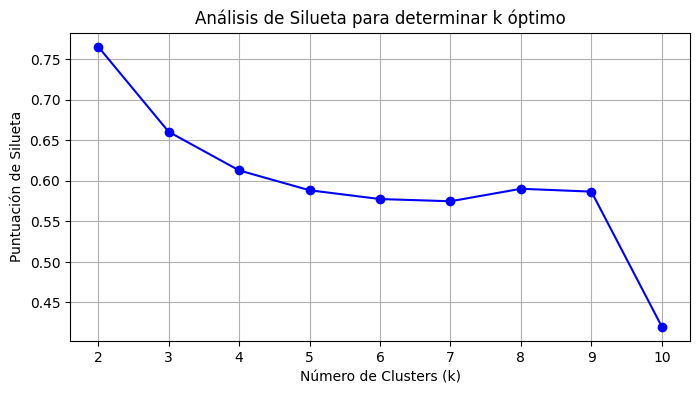

In [ ]:
# Rango de clusters a probar
rango_k = range(2, 11)
valores_silueta = []

for k in rango_k:
    kmeans_test = KMeans(n_clusters=k, n_init=10, random_state=42)
    etiquetas = kmeans_test.fit_predict(X)
    score = silhouette_score(X, etiquetas)
    valores_silueta.append(score)
    print(f"k={k}: Silueta = {score:.4f}")

# Graficar resultados
plt.figure(figsize=(8, 4))
plt.plot(rango_k, valores_silueta, 'bo-')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Puntuación de Silueta')
plt.title('Análisis de Silueta para determinar k óptimo')
plt.grid(True)
plt.show()

### **Configuración y Entrenamiento de K-Means**
Aquí se inicializa el algoritmo K-Means configurando `k = 3` (dado que el dataset Iris tiene 3 especies naturales).
* Se utiliza `n_init=10` para asegurar que el algoritmo se ejecute 10 veces con diferentes centroides iniciales para encontrar el mejor resultado.
* `fit_predict(X)` entrena el modelo y asigna a cada registro una etiqueta de grupo (cluster).

In [ ]:
# Decisión basada en conocimiento del dominio (biología), no solo en la métrica
k_final = 3

# Entrenamos el modelo definitivo
kmeans = KMeans(n_clusters=k_final, n_init=10, random_state=42)
y_pred = kmeans.fit_predict(X)

print(f"Modelo entrenado con k={k_final} clusters")

Modelo entrenado con k=3 clusters


### **Visualización de los Clusters y Centroides**
Se define una función para graficar los puntos de datos coloreados según el grupo asignado por el algoritmo. Además, se grafican con una **"X" roja** los centroides finales, que representan el "punto medio" o centro geométrico de cada uno de los tres grupos.

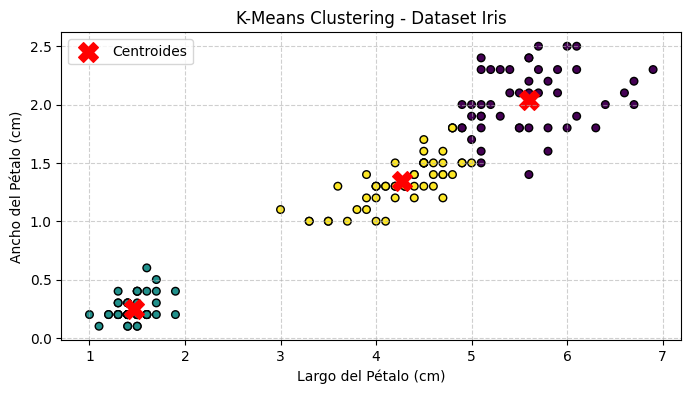

In [ ]:
# Visualización de los Clusters
def plot_clusters(X, y=None):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap='viridis', edgecolors='k')
    plt.xlabel("Largo del Pétalo (cm)")
    plt.ylabel("Ancho del Pétalo (cm)")

plt.figure(figsize=(8, 4))
plot_clusters(X, y_pred)
# Marcamos los centroides
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=200, c='red', marker='X', label='Centroides')
plt.title("K-Means Clustering - Dataset Iris")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### **Cálculo de Distancias y Detección de Anomalías**
Para identificar datos atípicos (anomalías), el código realiza lo siguiente:
1. Calcula la distancia de cada punto hacia su centroide asignado.
2. Para cada cluster, calcula el **percentil 95** de esas distancias.
3. Marca como **anomalía** cualquier punto que esté más alejado de su centroide que el 95% de los demás puntos de su mismo grupo.

In [ ]:
# Detección de Anomalías
# Calculamos la distancia de cada punto a su centroide asignado
distancias = kmeans.transform(X)
distancia_minima = distancias.min(axis=1)
labels = kmeans.labels_

# Identificamos outliers basados en el percentil 95 de cada cluster
es_anomalia = np.zeros(len(X), dtype=bool)

for i in range(k_final):
    # Filtramos las distancias que pertenecen solo al clúster i
    indices_del_cluster = (labels == i)
    distancias_cluster = distancia_minima[indices_del_cluster]

    # Calculamos el umbral específico para este clúster (percentil 95)
    if len(distancias_cluster) > 0:
        umbral_cluster = np.percentile(distancias_cluster, 95)

        # Marcamos como anomalía los puntos lejanos
        es_anomalia[indices_del_cluster] = distancias_cluster > umbral_cluster

### **Visualización Final de Resultados**
En la última celda se genera un gráfico comparativo:
* Los **puntos azules** representan los datos normales (dentro del rango común).
* Las **"X" rojas** resaltan los puntos detectados como anomalías.
Esto permite observar visualmente qué registros se comportan de forma inusual respecto a la tendencia de su grupo.

Total de anomalías detectadas: 9


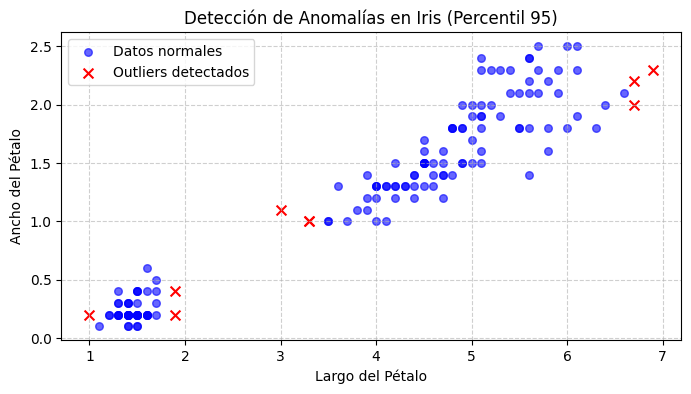

In [ ]:
# Visualizamos Resultados con Outliers
datos_limpios = X[~es_anomalia]
outliers = X[es_anomalia]

print(f"Total de anomalías detectadas: {es_anomalia.sum()}")

plt.figure(figsize=(8, 4))
plt.scatter(datos_limpios[:, 0], datos_limpios[:, 1], c='blue', s=30, alpha=0.6, label='Datos normales')
plt.scatter(outliers[:, 0], outliers[:, 1], c='red', s=50, marker='x', label='Outliers detectados')
plt.xlabel("Largo del Pétalo")
plt.ylabel("Ancho del Pétalo")
plt.title("Detección de Anomalías en Iris (Percentil 95)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()